<a href="https://colab.research.google.com/github/jungeun1228/2026_02_Tox21_ML_DL/blob/main/2026_Tox21_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import data


In [ ]:
# Download Tox21 dataset from Tox21 challenge website
!wget -O tox21_data.zip "https://tripod.nih.gov/tox21/challenge/download?id=tox21_10k_data_allsdf&sec="
!unzip tox21_data.zip
!ls

--2026-06-05 14:49:31--  https://tripod.nih.gov/tox21/challenge/download?id=tox21_10k_data_allsdf&sec=
Resolving tripod.nih.gov (tripod.nih.gov)... 128.231.19.105
Connecting to tripod.nih.gov (tripod.nih.gov)|128.231.19.105|:443... connected.
HTTP request sent, awaiting response... 200 
Length: unspecified [application/zip]
Saving to: ‘tox21_data.zip’

tox21_data.zip          [    <=>             ]   2.50M  2.68MB/s    in 0.9s    

2026-06-05 14:49:33 (2.68 MB/s) - ‘tox21_data.zip’ saved [2627177]

Archive:  tox21_data.zip
  inflating: tox21_10k_data_all.sdf  
sample_data  tox21_10k_data_all.sdf  tox21_data.zip


In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 15.9 MB/s eta 0:00:00


In [ ]:
# Canonicalization of SMILES

from rdkit import Chem
import numpy as np
import pandas as pd

sdf_path = "tox21_10k_data_all.sdf"
supplier = Chem.SDMolSupplier(sdf_path)

rows = []

for i, mol in enumerate(supplier):
    if mol is None:   # parsing 실패한 경우
        rows.append({
            "idx": i,
            "status": "parse_failed"
        })
        continue

    try:
        # 모든 SDF property 가져오기
        props = {k: mol.GetProp(k) for k in mol.GetPropNames()} # key-value dictionary 형태로 가져오기: raw 형태 그대로 가져옴 cf. props = mol.GetPropsAsDict() 숫자열로 가져옴
        # canonical smiles
        canonical_smiles = Chem.MolToSmiles(mol, canonical=True)

        row = {
            "idx": i,
            "canonical_smiles": canonical_smiles,
            "status": "ok",
        }

        # property들 합치기
        row.update(props)  # dict 병합

        rows.append(row)  # 리스트에 row 추가

    except Exception as e:
        rows.append({
            "idx": i,
            "status": f"failed: {str(e)}"
        })

df = pd.DataFrame(rows)
df.head()

[14:50:05] Explicit valence for atom # 3 Cl, 1, is greater than permitted
[14:50:05] ERROR: Could not sanitize molecule ending on line 21572
[14:50:05] ERROR: Explicit valence for atom # 3 Cl, 1, is greater than permitted
[14:50:07] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 1 ignored.
[14:50:07] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 1 ignored.
[14:50:07] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 6 ignored.
[14:50:07] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 6 ignored.
[14:50:11] Explicit valence for atom # 3 Cl, 1, is greater than permitted
[14:50:11] ERROR: Could not sanitize molecule ending on line 446665
[14:50:11] ERROR: Explicit valence for atom # 3 Cl, 1, is greater than permitted
[14:50:14] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[14:50:14] ERROR: Could not sanitize molecule ending on l

,idx,canonical_smiles,status,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD
0,0,C[n+]1c2cc(N)ccc2cc2ccc(N)cc21.Nc1ccc2cc3ccc(N...,ok,C27H25ClN6,468.9806 (35.4535+224.2805+209.2465),25848,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,O=C([O-])c1ccccc1-c1c2cc(Br)c(=O)c(Br)c-2oc2c(...,ok,C20H6Br4Na2O5,691.8542 (645.8757+22.9892+22.9892),5234,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,CO[C@@H]1[C@@H](OC)[C@H](C)[C@@](O)(CC(=O)[O-]...,ok,C47H83NO17,934.1584 (916.1205+18.0379),28909,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccccc2)c...,ok,C52H54N4O12,927.0048 (329.4575+89.0275+89.0275+329.4575+90...,5513,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,CC(=O)O.CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=...,ok,C66H87N17O14,1342.5025 (1282.4505+60.0520),26683,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Remove data rows with abnormal SMILES and complete duplicates

df_ok = df[df["status"] == "ok"].copy()
print(f"Original molecules: {len(df)} -> Molecules with normal SMILES: {len(df_ok)}")

print(f"Complete duplicates: {df_ok.drop(columns=["idx"]).duplicated().sum()}")

df_dedup = df_ok.drop(columns=["idx"]).drop_duplicates().reset_index(drop=True)
print(f"Molecules after removing complete duplicates: {len(df_dedup)}")

Original molecules: 11764 -> Molecules with normal SMILES: 11761
Complete duplicates: 281
Molecules after removing complete duplicates: 11480


In [ ]:
# # Duplicate with the same SMILES but with different labels -> combine them into single data as follows
# NaN + NaN → NaN
# NaN + 0 → 0 / NaN + 1 → 1
# 0 + 1 → NaN (충돌)

print(f"Duplicates with the same SMILES: {df_ok.duplicated(subset="canonical_smiles").sum()}")

def duplicate_combine(series):
    # 숫자로 변환 (문자열 "0","1" 처리)
    vals = pd.to_numeric(series, errors="coerce").dropna().unique() # 숫자로 변환하다가 실패하면: 에러발생대신, NaN으로 바꿔라

    if len(vals) == 0:
        return np.nan          # 전부 NaN
    if len(vals) == 1:
        return int(vals[0])    # 0 또는 1 하나만 있음
    else:
        return np.nan          # 0과 1 둘 다 있음 → 충돌

Duplicates with the same SMILES: 3720


In [ ]:
# Apply to the endpoint_column

# 1-1. aggregation dict 만들기 & aggregation의 메타 정보는 첫 값 사용 (필요에 따라 조정)
meta_column = ['idx', 'canonical_smiles', 'Formula', 'FW', 'DSSTox_CID']  # excluded 'status'
agg_dict = {col: "first" for col in meta_column}

# 1-2. aggregation의 endpoint 정보는 duplicate_combine 함수 사용
endpoint_column = df_ok.columns[6:]
for col in endpoint_column:
    agg_dict[col] = duplicate_combine
# 2. smiles 기준 그룹화
df_grouped = df_ok.groupby("canonical_smiles", as_index=False).agg(agg_dict)

print(df_ok.shape, "→", df_grouped.shape)

(11761, 18) → (8041, 17)


In [ ]:
# Filter out data with only NaN values for all endpoints (e.g., data only with chemical information)
print(f"Before filtering: df_grouped {df_grouped.shape}")
df_filtered = df_grouped.dropna(subset=endpoint_column, how="all")
print(f"After filtering: df_filtered {df_filtered.shape}")
print("It turned out that all chemicals has toxicity data from at least one endpoint.")

Before filtering: df_grouped (8041, 17)
After filtering: df_filtered (8041, 17)
It turned out that all chemicals has toxicity data from at least one endpoint.


In [ ]:
# Create Morgan Fingerprint

from rdkit.Chem import rdFingerprintGenerator

# Morgan generator 생성
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def smiles_to_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return morgan_gen.GetFingerprintAsNumPy(mol)

def build_morgan_fp_to_df(df, smiles_col="smiles", expand_bits=True, keep_fp_array=False):
    df = df.copy()

    fps = []
    is_valid_list = []

    for smi in df[smiles_col]:
        fp = smiles_to_morgan_fp(smi)
        fps.append(fp)
        is_valid_list.append(fp is not None)

    df["fp_valid"] = is_valid_list

    if expand_bits: # Create DataFrame with Morgan FP with expanded bits - Morgan FP의 각 bit이 하나의 column 이 됨
        valid_fps = [fp for fp in fps if fp is not None]

        fp_array = np.stack(valid_fps)
        fp_cols = [f"fp_{i}" for i in range(fp_array.shape[1])]

        fp_df = pd.DataFrame(fp_array, columns=fp_cols, index=df.index[df["fp_valid"]])

        df = pd.concat([df, fp_df], axis=1)

    if keep_fp_array: # keep fp in array format in seperate column
        df["morgan_fp"] = fps

    return df

In [ ]:
# apply the function to create fingerprint
df_w_fp = build_morgan_fp_to_df(df_filtered, smiles_col="canonical_smiles", expand_bits=True, keep_fp_array=False)
df_w_fp.head(3)

[14:50:58] WARNING: not removing hydrogen atom without neighbors


,idx,canonical_smiles,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,687,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,C17H22BrNO4,384.2649 (303.3529+80.9119),25419,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,5652,Br.CC(N)Cc1ccc(O)cc1,C9H14BrNO,232.1176 (80.9119+151.2056),25961,NaN,0.0,NaN,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,3557,Br.CCCCCCCCN1C=CN(C)C1,C12H25BrN2,277.2443 (196.3324+80.9119),29288,0.0,0.0,0.0,NaN,0.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(f"Original df (df_filtered): {len(df_filtered)} molecules \nValid SMILES: {df_w_fp['fp_valid'].sum()} molecules -> successfully converted to morgan fingerprint in df_w_fp")
print(df_w_fp.shape)

Original df (df_filtered): 8041 molecules 
Valid SMILES: 8041 molecules -> successfully converted to morgan fingerprint in df_w_fp
(8041, 2066)


In [ ]:
# calculate RDKit descritors

from rdkit.Chem import Descriptors, Lipinski, Crippen, rdMolDescriptors, rdmolops

def calc_basic_descriptors(smiles):       # 11 descriptors
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return {
        "MolWt": Descriptors.MolWt(mol),  # 분자량
        "MolLogP": Crippen.MolLogP(mol),  # 지용성
        "TPSA": rdMolDescriptors.CalcTPSA(mol), # 극성 (topological polar surface area)
        "NumHDonors": Lipinski.NumHDonors(mol), # H-bond donor
        "NumHAcceptors": Lipinski.NumHAcceptors(mol), # H-bond acceptor
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol), # 구조 유연성
        "RingCount": Lipinski.RingCount(mol), # ring 있는지
        "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol), #aromatic ring 있는지
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol), # sp3 hybridized carbon 비율 1에 가까울수록 saturated (chain-like): 3D 구조 높음
        "HeavyAtomCount": Lipinski.HeavyAtomCount(mol), # 무거운 원자 수                      0에 가까울수록 aromatic (sp2구조): planar - stacking/aromatic interactions
        "FormalCharge": rdmolops.GetFormalCharge(mol)
    }

In [ ]:
# apply the function to calculate basic descriptors
desc_df = df_w_fp["canonical_smiles"].apply(calc_basic_descriptors).apply(pd.Series)  # Series: None vs. DataFrame (pd): NaN으로 통일
# concatenate desc_df into the original df                                          # -> apply(pd.Series) 하면 df화 되면서 invalid 값은 NaN이 생김
df_w_fp_desc = pd.concat([df_w_fp, desc_df], axis=1)

[14:51:03] WARNING: not removing hydrogen atom without neighbors


In [ ]:
# create valid column for descriptors
desc_cols = [
    "MolWt", "MolLogP", "TPSA", "NumHDonors", "NumHAcceptors",
    "NumRotatableBonds", "RingCount", "NumAromaticRings",
    "FractionCSP3", "HeavyAtomCount", "FormalCharge"
]

df_w_fp_desc["desc_valid"] = df_w_fp_desc[desc_cols].notna().all(axis=1) # 이 row에서 모든 값이 NaN이 아니면 True
print(df_w_fp_desc.head(3))
print(f"Among {len(df_w_fp_desc)} molecules, we got all valid descriptors from {df_w_fp_desc['desc_valid'].sum()} molecules.")

# create df only using molecules with valid Morgan FP & descriptors (valid_df)
valid_df = df_w_fp_desc[df_w_fp_desc["fp_valid"] & df_w_fp_desc["desc_valid"]].copy()

    idx                         canonical_smiles      Formula  \
0   687  Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1  C17H22BrNO4   
1  5652                     Br.CC(N)Cc1ccc(O)cc1    C9H14BrNO   
2  3557                   Br.CCCCCCCCN1C=CN(C)C1   C12H25BrN2   

                            FW DSSTox_CID  SR-HSE  NR-AR  SR-ARE  \
0  384.2649 (303.3529+80.9119)      25419     0.0    0.0     0.0   
1  232.1176 (80.9119+151.2056)      25961     NaN    0.0     NaN   
2  277.2443 (196.3324+80.9119)      29288     0.0    0.0     0.0   

   NR-Aromatase  NR-ER-LBD  ...   TPSA  NumHDonors  NumHAcceptors  \
0           0.0        0.0  ...  92.95         5.0            5.0   
1           0.0        0.0  ...  46.25         2.0            2.0   
2           NaN        0.0  ...   6.48         0.0            2.0   

   NumRotatableBonds  RingCount  NumAromaticRings  FractionCSP3  \
0                6.0        2.0               2.0      0.294118   
1                2.0        1.0               1.0      

In [ ]:
# Derive scaffold

from rdkit.Chem.Scaffolds import MurckoScaffold

def make_scaffold(smiles):    # side chain 제거하고 core만 남김
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    return scaffold

In [ ]:
valid_df["scaffold"] = valid_df["canonical_smiles"].apply(make_scaffold)
valid_df

[14:51:09] WARNING: not removing hydrogen atom without neighbors


,idx,canonical_smiles,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,...,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,NumAromaticRings,FractionCSP3,HeavyAtomCount,FormalCharge,desc_valid,scaffold
0,687,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,C17H22BrNO4,384.2649 (303.3529+80.9119),25419,0.0,0.0,0.0,0.0,0.0,...,5.0,5.0,6.0,2.0,2.0,0.294118,23.0,0.0,True,c1ccc(CCNCCc2ccccc2)cc1
1,5652,Br.CC(N)Cc1ccc(O)cc1,C9H14BrNO,232.1176 (80.9119+151.2056),25961,NaN,0.0,NaN,0.0,0.0,...,2.0,2.0,2.0,1.0,1.0,0.333333,12.0,0.0,True,c1ccccc1
2,3557,Br.CCCCCCCCN1C=CN(C)C1,C12H25BrN2,277.2443 (196.3324+80.9119),29288,0.0,0.0,0.0,NaN,0.0,...,0.0,2.0,7.0,1.0,0.0,0.833333,15.0,0.0,True,C1=CNCN1
3,10209,Br.CCCCN1C=CN(C)C1,C8H17BrN2,221.1380 (140.2260+80.9119),29321,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,3.0,1.0,0.0,0.750000,11.0,0.0,True,C1=CNCN1
4,10207,Br.CCCN1C=CN(C)C1,C7H15BrN2,207.1114 (126.1995+80.9119),29320,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,2.0,1.0,0.0,0.714286,10.0,0.0,True,C1=CNCN1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8036,10353,c1coc(Cn2cccc2)c1,C9H9NO,147.1739,27663,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,2.0,2.0,0.111111,11.0,0.0,True,c1coc(Cn2cccc2)c1
8037,5295,c1csc(-c2ccc(-c3cccs3)s2)c1,C12H8S3,248.3869,21206,1.0,1.0,1.0,NaN,NaN,...,0.0,3.0,2.0,3.0,3.0,0.000000,15.0,0.0,True,c1csc(-c2ccc(-c3cccs3)s2)c1
8038,5677,c1csc(C2(N3CCCCC3)CCCCC2)c1,C15H23NS,249.4148,26168,NaN,0.0,NaN,0.0,0.0,...,0.0,2.0,2.0,3.0,1.0,0.733333,17.0,0.0,True,c1csc(C2(N3CCCCC3)CCCCC2)c1
8039,7302,c1csc(SSc2cccs2)c1,C8H6S4,230.3932,27476,1.0,0.0,0.0,NaN,0.0,...,0.0,4.0,3.0,2.0,2.0,0.000000,12.0,0.0,True,c1csc(SSc2cccs2)c1


In [ ]:
# Label df

target_cols = ["NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase", "NR-ER", "NR-ER-LBD",
               "NR-PPAR-gamma", "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"]

label_cols = ["canonical_smiles", "DSSTox_CID", "Formula", "scaffold", "fp_valid", "desc_valid"]

label_df = pd.concat([valid_df[label_cols], valid_df[target_cols]], axis = 1) # target 컬럼도 포함인지 확인하기

# Morgan df

morgan_cols = [col for col in valid_df.columns if col.startswith("fp_") and col[3:].isdigit()]  #  fp_로 시작 & 숫자 1개 이상

morgan_df = pd.concat([valid_df["canonical_smiles"], valid_df[morgan_cols]], axis=1)

# Descriptor df
desc_cols = [
    "MolWt", "MolLogP", "TPSA", "NumHDonors", "NumHAcceptors",
    "NumRotatableBonds", "RingCount", "NumAromaticRings",
    "FractionCSP3", "HeavyAtomCount", "FormalCharge"
]

desc_df = pd.concat([valid_df["canonical_smiles"], valid_df[desc_cols]], axis=1)

# Check shapes of each df
print(label_df.shape)
print(morgan_df.shape)
print(desc_df.shape)

(8041, 18)
(8041, 2049)
(8041, 12)


In [ ]:
# merged_df = label_df.merge(morgan_df, on="canonical_smiles")\
#                     .merge(desc_df, on="canonical_smiles")
# merged_df.shape

In [ ]:
# # 전체 코드: 처음부터 split까지

# 아래 코드는:

# 병합
# scaffold split
# scaling
# concat
# y 생성

# 까지 한 번에 해준다.

# X, y split

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler


# =========================================================
# 0. 설정
# =========================================================
merge_key = "canonical_smiles"

non_feature_cols_morgan = [merge_key]
non_feature_cols_desc = [merge_key]
meta_cols = [merge_key, "scaffold"] + target_cols


# =========================================================
# 1. 데이터 병합
# =========================================================
def build_merged_tox21_df(
    morgan_df,
    desc_df,
    label_df,
    merge_key,
    target_cols,
    scaffold_col="scaffold"
):
    # 필요한 컬럼 확인
    assert merge_key in morgan_df.columns, f"{merge_key} not in morgan_df"
    assert merge_key in desc_df.columns, f"{merge_key} not in desc_df"
    assert merge_key in label_df.columns, f"{merge_key} not in label_df"
    assert scaffold_col in label_df.columns, f"{scaffold_col} not in label_df"

    for c in target_cols:
        assert c in label_df.columns, f"{c} not in label_df"

    merged = (
        label_df[[merge_key, scaffold_col] + target_cols]
        .merge(morgan_df, on=merge_key, how="inner")
        .merge(desc_df, on=merge_key, how="inner")
        .copy()
    )

    # index 정리
    merged = merged.reset_index(drop=True)

    return merged


# # =========================================================
# # 2. feature column 추출
# # =========================================================
# def get_feature_columns(
#     merged_df,
#     merge_key,
#     target_cols,
#     scaffold_col="scaffold",
#     morgan_prefix=None,
#     desc_prefix=None
# ):
#     """
#     prefix가 있으면 그걸 우선 사용.
#     예: morgan_0 ... morgan_2047 / desc_MolWt ...
#     prefix가 없으면 전체에서 meta cols 제외한 뒤,
#     morgan_df/desc_df 기준으로 따로 지정하는 방식 권장.
#     """
#     meta_cols = [merge_key, scaffold_col] + target_cols
#     feature_cols = [c for c in merged_df.columns if c not in meta_cols]

#     if morgan_prefix is not None:
#         morgan_cols = [c for c in feature_cols if c.startswith(morgan_prefix)]
#     else:
#         # 예시: Morgan이 2048개고 이름이 따로 정리되어 있다면 직접 수정 권장
#         morgan_cols = [c for c in feature_cols if "morgan" in c.lower()]

#     if desc_prefix is not None:
#         desc_cols = [c for c in feature_cols if c.startswith(desc_prefix)]
#     else:
#         desc_cols = [c for c in feature_cols if c not in morgan_cols]

#     return morgan_cols, desc_cols


# =========================================================
# 2. scaffold split
# =========================================================
def scaffold_train_val_test_split(
    df,
    scaffold_col="scaffold",
    frac_train=0.8,
    frac_val=0.1,
    frac_test=0.1,
    random_state=42
):
    """
    scaffold 단위로 split.
    같은 scaffold는 train/val/test 중 하나에만 들어감.
    그룹 크기 큰 scaffold부터 배치해서 비율을 맞추는 단순 greedy 방식.
    핵심 목표는: 같은 scaffold는 한 split에만 들어가게 하고 & 전체 샘플 수가 가능한 한 train:val:test = 0.8:0.1:0.1에 가깝게 맞도록 하는 것
    즉 이 코드는 GSS보다 더 직접적으로 "group 유지 + split 비율 맞추기"를 노리고 있어요.
    cf. GroupShuffleSplit은:scaffold 단위 분리는 보장되지만 샘플 수 비율이 정확히 맞는 건 아님 특히 group 크기 편차가 크면 train/val/test 비율이 꽤 흔들릴 수 있어요.
    [Split 방식]
    1. 랜덤 split: 가장 쉬움 / 성능은 잘 나오지만 leakage 가능성 큼
    2. GroupShuffleSplit or GroupKFold: scaffold/group leakage 방지 / 표준적 (sklearn 인터페이스라 익숙함)
    3. 커스텀 scaffold split (greedy / deterministic / DeepChem 스타일): 화학 ML에서 매우 흔함 / 논문 재현이나 benchmark에서 자주 사용
    -> 즉, 일반 실무 전체로 보면 sklearn group split이 더 흔하고, 분자/화학 ML 쪽으로 좁히면 scaffold custom split도 아주 흔하다고 보면 됩니다.
    """
    assert np.isclose(frac_train + frac_val + frac_test, 1.0), "fractions must sum to 1"

    rng = np.random.RandomState(random_state)

    scaffold_to_indices = df.groupby(scaffold_col).indices
    scaffold_items = list(scaffold_to_indices.items())

    # 크기 내림차순, 같은 크기면 random tie-break
    scaffold_items = sorted(
        scaffold_items,
        key=lambda x: (len(x[1]), rng.rand()),
        reverse=True
    )

    n_total = len(df)
    target_train = frac_train * n_total
    target_val = frac_val * n_total
    target_test = frac_test * n_total

    train_idx, val_idx, test_idx = [], [], []
    n_train = n_val = n_test = 0

    for scaffold, idxs in scaffold_items:
        group_size = len(idxs)

        # 현재 부족한 쪽으로 넣는 greedy
        deficits = {
            "train": target_train - n_train,
            "val": target_val - n_val,
            "test": target_test - n_test
        }

        # deficit 큰 순서대로 후보 선택
        split_name = max(deficits, key=deficits.get)

        if split_name == "train":
            train_idx.extend(idxs)
            n_train += group_size
        elif split_name == "val":
            val_idx.extend(idxs)
            n_val += group_size
        else:
            test_idx.extend(idxs)
            n_test += group_size

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)

    return train_df, val_df, test_df


# =========================================================
# 3. X / y 만들기
# =========================================================
def make_xy_from_split(
    train_df,
    val_df,
    test_df,
    morgan_cols,
    desc_cols,
    target_cols
):
    # Morgan
    # Morgan fingerprint는 scaler하면 값이 깨짐 -> 하면 의미 망가짐, scaling 불필요
    X_morgan_train = train_df[morgan_cols].to_numpy(dtype=np.float32)
    X_morgan_val = val_df[morgan_cols].to_numpy(dtype=np.float32)
    X_morgan_test = test_df[morgan_cols].to_numpy(dtype=np.float32)

    # Descriptor
    X_desc_train = train_df[desc_cols].to_numpy(dtype=np.float32)
    X_desc_val = val_df[desc_cols].to_numpy(dtype=np.float32)
    X_desc_test = test_df[desc_cols].to_numpy(dtype=np.float32)

    # descriptor는 train 기준으로만 scaling (*val/test는 transform만 해야 data leakage 없음)
    scaler = StandardScaler()
    X_desc_train_scaled = scaler.fit_transform(X_desc_train)
    X_desc_val_scaled = scaler.transform(X_desc_val)
    X_desc_test_scaled = scaler.transform(X_desc_test)

    # concat
    X_train = np.concatenate([X_morgan_train, X_desc_train_scaled], axis=1)
    X_val = np.concatenate([X_morgan_val, X_desc_val_scaled], axis=1)
    X_test = np.concatenate([X_morgan_test, X_desc_test_scaled], axis=1)

    # y
    y_train = train_df[target_cols].to_numpy(dtype=np.float32)
    y_val = val_df[target_cols].to_numpy(dtype=np.float32)
    y_test = test_df[target_cols].to_numpy(dtype=np.float32)

    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "scaler": scaler
    }


# =========================================================
# 4. split 요약 확인
# =========================================================
def summarize_split(split_df, name, target_cols, scaffold_col="scaffold"):
    print(f"\n[{name}]")
    print(f"n_samples = {len(split_df)}")
    print(f"n_scaffolds = {split_df[scaffold_col].nunique()}")

    rows = []
    for c in target_cols:
        y = split_df[c].to_numpy()
        valid = ~pd.isna(y)
        yv = y[valid]

        rows.append({
            "target": c,
            "n_labeled": len(yv),
            "positive_ratio": np.nan if len(yv) == 0 else np.mean(yv)
        })

    summary_df = pd.DataFrame(rows)
    print(summary_df)
    return summary_df

In [ ]:
# 1) 병합
merged_df = build_merged_tox21_df(
    morgan_df=morgan_df,
    desc_df=desc_df,
    label_df=label_df,
    merge_key=merge_key,
    target_cols=target_cols,
    scaffold_col="scaffold"
)

print("merged_df shape:", merged_df.shape)
display(merged_df.head())

merged_df shape: (8041, 2073)


,canonical_smiles,scaffold,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,...,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,NumAromaticRings,FractionCSP3,HeavyAtomCount,FormalCharge
0,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,c1ccc(CCNCCc2ccccc2)cc1,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,...,2.6355,92.95,5.0,5.0,6.0,2.0,2.0,0.294118,23.0,0.0
1,Br.CC(N)Cc1ccc(O)cc1,c1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,1.8598,46.25,2.0,2.0,2.0,1.0,1.0,0.333333,12.0,0.0
2,Br.CCCCCCCCN1C=CN(C)C1,C1=CNCN1,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,...,3.6009,6.48,0.0,2.0,7.0,1.0,0.0,0.833333,15.0,0.0
3,Br.CCCCN1C=CN(C)C1,C1=CNCN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0405,6.48,0.0,2.0,3.0,1.0,0.0,0.750000,11.0,0.0
4,Br.CCCN1C=CN(C)C1,C1=CNCN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.6504,6.48,0.0,2.0,2.0,1.0,0.0,0.714286,10.0,0.0


In [ ]:
# # feature 컬럼 지정
# # 예시: morgan_df / desc_df 원본 컬럼 기준
# morgan_cols = [c for c in morgan_df.columns if c != merge_key]
# desc_cols = [c for c in desc_df.columns if c != merge_key]


# # # 위에꺼는 방법 2이고 이게 위 합수활용한 버전 - 나는 내 데이터랑 맞게 조절하기

# # morgan_cols, desc_cols = get_feature_columns(
# #     merged_df,
# #     merge_key=merge_key,
# #     target_cols=target_cols,
# #     scaffold_col="scaffold",
# #     morgan_prefix="morgan_",
# #     desc_prefix="desc_"
# # )

# # print("n_morgan_cols:", len(morgan_cols))
# # print("n_desc_cols:", len(desc_cols))

In [ ]:
# Split
train_df, val_df, test_df = scaffold_train_val_test_split(
    df=merged_df,
    scaffold_col="scaffold",
    frac_train=0.8,
    frac_val=0.1,
    frac_test=0.1,
    random_state=42
)

summarize_split(train_df, "train", target_cols)
summarize_split(val_df, "val", target_cols)
summarize_split(test_df, "test", target_cols)


[train]
n_samples = 6433
n_scaffolds = 954
           target  n_labeled  positive_ratio
0           NR-AR       5965        0.035205
1       NR-AR-LBD       5622        0.031128
2          NR-AhR       5412        0.103289
3    NR-Aromatase       4886        0.039091
4           NR-ER       5065        0.103258
5       NR-ER-LBD       5733        0.042386
6   NR-PPAR-gamma       5397        0.024458
7          SR-ARE       4926        0.143727
8        SR-ATAD5       5859        0.030722
9          SR-HSE       5423        0.046100
10         SR-MMP       4854        0.141533
11         SR-p53       5615        0.050935

[val]
n_samples = 804
n_scaffolds = 687
           target  n_labeled  positive_ratio
0           NR-AR        734        0.042234
1       NR-AR-LBD        646        0.037152
2          NR-AhR        627        0.145136
3    NR-Aromatase        521        0.082534
4           NR-ER        573        0.120419
5       NR-ER-LBD        685        0.051095
6   NR-PPAR-gam

,target,n_labeled,positive_ratio
0,NR-AR,718,0.027855
1,NR-AR-LBD,639,0.032864
2,NR-AhR,631,0.145800
3,NR-Aromatase,531,0.096045
4,NR-ER,557,0.125673
5,NR-ER-LBD,664,0.037651
6,NR-PPAR-gamma,596,0.036913
7,SR-ARE,491,0.211813
8,SR-ATAD5,682,0.045455
9,SR-HSE,578,0.083045


In [ ]:
# X, y 생성
data_dict = make_xy_from_split(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    morgan_cols=morgan_cols,
    desc_cols=desc_cols,
    target_cols=target_cols
)

X_train = data_dict["X_train"]
X_val = data_dict["X_val"]
X_test = data_dict["X_test"]

y_train = data_dict["y_train"]
y_val = data_dict["y_val"]
y_test = data_dict["y_test"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (6433, 2059)
X_val: (804, 2059)
X_test: (804, 2059)
y_train: (6433, 12)
y_val: (804, 12)
y_test: (804, 12)


# Train / Evaluate

In [ ]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score


# =========================
# 0. Set seed
# =========================

def set_seed(seed=42):  # 재현성: 같은 결과가 나오도록 (config 비교 시 특히 중요)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# =========================
# 1. Dataset
# =========================
class Tox21MLPDataset(Dataset): # Dataset = “데이터를 하나씩 꺼내는 규칙을 정의하는 클래스” / pytorch 구조) Dataset:"데이터 하나는 이렇게 생겼다"
    def __init__(self, X, y):                                                                   # -> DataLoader: "이걸 batch로 묶어줘"
        """                                                                                     # -> 모델: "batch 받아서 학습"
        X: np.ndarray, shape (N, input_dim)
        y: np.ndarray, shape (N, n_tasks), can contain np.nan
        """
        self.X = torch.tensor(X, dtype=torch.float32) # numpy → torch tensor
        self.y = torch.tensor(np.nan_to_num(y, nan=0.0), dtype=torch.float32) # NaN을 임시로 0으로 바꿈 (일단 loss계산에서 1차로 포함되어서 placeholder로 넣어두지만, 이후 계산 단계에서 mask로 걸러내짐)
        self.mask = torch.tensor(~np.isnan(y), dtype=torch.float32) # label 있는 곳: 1 / 없는 곳: 0

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "x": self.X[idx],
            "y": self.y[idx],
            "mask": self.mask[idx]
        }


# =========================
# 2. Model
# =========================
class Tox21MLP(nn.Module):
    def __init__(self, input_dim, n_tasks=12, hidden_dims=(1024, 512), dropout=0.3):  # 학습할 때 30% 뉴런을 랜덤하게 끈다
        super().__init__()                                                            # overfitting 방지 & ensemble 효과 (여러 모델을 평균내는 효과) & robustness 증가

        h1, h2 = hidden_dims

        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1), # descriptor 분포가 안정적이지 않으면 LayerNorm으로 바꾸는 경우도 있음.
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(h1, h2),  # 특징추출
            nn.BatchNorm1d(h2), # 안정화
            nn.ReLU(),          # 비선형성
            nn.Dropout(dropout),  # 일반화

            nn.Linear(h2, n_tasks)  # 각 task의 logits 출력
        )

    def forward(self, x):
        return self.net(x)  # logits (각 task에 대한 “raw score (점수)


# =========================
# 3. Pos weight 계산
# =========================
def compute_pos_weight(y_train):
    """
    y_train: np.ndarray, shape (N, n_tasks), with np.nan
    반환: torch.FloatTensor of shape (n_tasks,)
    pos_weight = n_negative / n_positive
    """
    pos_weights = []  # positive(1) 클래스에 더 큰 중요도를 주기 위한 가중치 (pos_weight = n_negative / n_positive)
                                                                   # neg가 pos보다 9배 많으면, pos를 9배 중요하게 보겠다.
    for t in range(y_train.shape[1]): # task별로 반복               # 왜 필요하냐? 모델이 그냥 학습하면 "0이 훨씬 많네? 그냥 다 0으로 예측하면 되겠네
        y_t = y_train[:, t]                                        # pos_weight이 있으면 "positive 틀림 → 더 크게 벌점 / negative 틀림 → 덜 벌점
        valid = ~np.isnan(y_t)  # NaN 제거                          # => binary classification + imbalance 있을 때 거의 필수
        y_valid = y_t[valid]

        n_pos = np.sum(y_valid == 1)  # positive / negative 개수 계산
        n_neg = np.sum(y_valid == 0)

        if n_pos == 0:
            pos_weights.append(1.0) # 예외 처리 - positive 없으면, 그냥 weight 1로 둠 (neutral)
        else:
            pos_weights.append(n_neg / max(n_pos, 1)) # weight 계산

    return torch.tensor(pos_weights, dtype=torch.float32)


# =========================
# 4. Masked BCE loss
# =========================
def masked_bce_with_logits_loss(logits, targets, mask, pos_weight=None):  # NaN(라벨 없는 부분)을 무시하고 BCE loss를 계산
    """
    B: batch size, T: number of tasks/targets (T = 12)
    logits: (B, T)
    targets: (B, T)
    mask: (B, T), 1 if valid else 0
    pos_weight: (T,)
    """
    loss_fn = nn.BCEWithLogitsLoss(reduction="none", pos_weight=pos_weight) # reduction="none": 평균 안 냄 -> task별 loss를 유지해서 mask 적용하려고
    loss = loss_fn(logits, targets)   # (B, T)                              # 원래는 그냥 바로 평균 내버림 (우리는 mask적용해야하므로 element-wise loss 유지 )
    loss = loss * mask

    denom = mask.sum()  # 실제로 loss에 포함된 valid 개수
    if denom.item() == 0:
        return loss.sum()
    return loss.sum() / denom # 수동 평균 (NaN 제외)


# =========================
# 5. Train / Eval loop
# =========================
def train_one_epoch(model, loader, optimizer, device, pos_weight=None):
    model.train()
    total_loss = 0.0
    total_count = 0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        mask = batch["mask"].to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = masked_bce_with_logits_loss(logits, y, mask, pos_weight=pos_weight)
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)


@torch.no_grad()  # 이 함수에 대해서 gradient 계산을 완전히 끄는 설정 (predict에서는 학습 안하는데도, gradient를 자동계산해버리면 메모리낭비, 속도 저하라서)
def predict(model, loader, device):               # context manager랑 동일 (with torch.no_grad(): logits = model(x))
    model.eval()

    all_logits = []
    all_y = []
    all_mask = []

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].cpu().numpy()
        mask = batch["mask"].cpu().numpy()

        logits = model(x).cpu().numpy()

        all_logits.append(logits)
        all_y.append(y)
        all_mask.append(mask)

    all_logits = np.concatenate(all_logits, axis=0)
    all_y = np.concatenate(all_y, axis=0)
    all_mask = np.concatenate(all_mask, axis=0)

    probs = 1 / (1 + np.exp(-all_logits))
    return probs, all_y, all_mask

@torch.no_grad()  # for val loss calculation (train_one_epoch랑 거의 똑같지만 backward 없음 + no_grad 있음)
def evaluate_loss(model, loader, device, pos_weight=None):
    model.eval()

    total_loss = 0.0
    total_count = 0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        mask = batch["mask"].to(device)

        logits = model(x)
        loss = masked_bce_with_logits_loss(logits, y, mask, pos_weight=pos_weight)

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)

def evaluate_multitask(model, loader, device, task_names=None):
    probs, y_true, mask = predict(model, loader, device)

    n_tasks = y_true.shape[1]
    rows = []

    for t in range(n_tasks):
        valid = mask[:, t].astype(bool)
        y_t = y_true[valid, t]
        p_t = probs[valid, t]

        if len(y_t) == 0 or len(np.unique(y_t)) < 2:
            rows.append({
                "task": task_names[t] if task_names is not None else f"task_{t}",
                "roc_auc": np.nan,
                "pr_auc": np.nan,
                "n_valid": len(y_t),
                "positive_ratio": np.nan if len(y_t) == 0 else y_t.mean()
            })
            continue

        rows.append({
            "task": task_names[t] if task_names is not None else f"task_{t}",
            "roc_auc": roc_auc_score(y_t, p_t),
            "pr_auc": average_precision_score(y_t, p_t),
            "n_valid": len(y_t),
            "positive_ratio": y_t.mean()
        })

    df = pd.DataFrame(rows)
    summary = {
        "mean_roc_auc": df["roc_auc"].mean(skipna=True),
        "mean_pr_auc": df["pr_auc"].mean(skipna=True),
        "per_task_df": df
    }
    return summary


# =========================
# 6. Early stopping training
# =========================
def fit_tox21_mlp(  # 모델을 학습(train)하고, validation 성능을 보면서 자동으로 멈추고, 가장 좋은 모델을 반환하는 함수
    X_train,        # 왜 하냐? 학습 계속하면, train set 성능만 좋아지고 val set 성능은 감소 (overfitting)
    y_train,        # -> val 성능이 최고일때 멈추자.
    X_val,
    y_val,
    task_names=None,
    hidden_dims=(1024, 512),
    dropout=0.3,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-5,
    max_epochs=100,
    patience=15,  # 매 epoch마다 validation 평가 -> 성능 안 좋아지면 patience 카운트 -> 일정 횟수 넘으면 자동 종료 (early stopping)
    selection_metric="roc_auc",   # "roc_auc" or "pr_auc"                         # -> 가장 좋은 모델로 복원
    device=None
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Create dataset and data loader
    train_ds = Tox21MLPDataset(X_train, y_train)
    val_ds = Tox21MLPDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    input_dim = X_train.shape[1]
    n_tasks = y_train.shape[1]

    # Create model
    model = Tox21MLP(
        input_dim=input_dim,
        n_tasks=n_tasks,
        hidden_dims=hidden_dims,
        dropout=dropout
    ).to(device)

    # Calculate pos_weight (due to class imbalance)
    pos_weight = compute_pos_weight(y_train).to(device)

    # Set optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # Initialize early stopping parameters
    best_state = None
    best_score = -np.inf
    best_epoch = -1
    best_val_roc_auc = -np.inf
    best_val_pr_auc = -np.inf
    patience_counter = 0

    history = []
    per_task_history = []

    # Training loop
    # 1. Train
    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            pos_weight=pos_weight
        )
    # 2. Evaluate with val set (* 여기서 핵심: 모델을 "loss"가 아니라 "PR-AUC" 기준으로 평가 - imbalance 데이터에서는 PR-AUC가 더 중요)
        val_loss = evaluate_loss(model, val_loader, device, pos_weight=pos_weight)

        val_summary = evaluate_multitask(model, val_loader, device, task_names=task_names)
        val_pr_auc = val_summary["mean_pr_auc"]
        val_roc_auc = val_summary["mean_roc_auc"]
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mean_pr_auc": val_pr_auc,
            "val_mean_roc_auc": val_roc_auc
        })

        tmp = val_summary["per_task_df"].copy()
        tmp["epoch"] = epoch
        per_task_history.append(tmp)

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_mean_pr_auc={val_pr_auc:.4f} | "
            f"val_mean_roc_auc={val_roc_auc:.4f}"
        )

        # Early Stopping logics

        score = val_roc_auc if selection_metric == "roc_auc" else val_pr_auc

        if score > best_score:           # "current model performs the best"
            best_score = score           # -> 선택 지표 기준으로 best 갱신
            best_epoch = epoch
            best_val_roc_auc = val_roc_auc   # 두 지표 모두 기록해 둠
            best_val_pr_auc = val_pr_auc
            patience_counter = 0        # reset patience
            best_state = {"model_state_dict": model.state_dict()}
        else:
            patience_counter += 1          # when performance is not the best (when PR-AUC does not get better)

        if patience_counter >= patience:        # stopping condition
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state["model_state_dict"]) # load the best model

    history_df = pd.DataFrame(history)
    per_task_history_df = pd.concat(per_task_history, ignore_index=True)
    best_info = {
            "best_epoch": best_epoch,
            "best_val_roc_auc": best_val_roc_auc,
            "best_val_pr_auc": best_val_pr_auc,
            "selection_metric": selection_metric,
        }

    return model, history_df, per_task_history_df, best_info


# Run code

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"

set_seed(42)

model_v1, history_v1_df, per_task_history_v1_df, best_info_v1 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(512, 256),  # 2차때는 1024, 512
    dropout=0.2,          # 2차때는 0.3
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-5,
    max_epochs=100,
    patience=5,
    selection_metric="roc_auc",
    device=None  # 자동으로 cuda / cpu 선택
)

# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v1_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v1["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v1["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v1["best_val_pr_auc"], 4))

Epoch 001 | train_loss=0.9913 | val_loss=1.2740 | val_mean_pr_auc=0.3650 | val_mean_roc_auc=0.7847
Epoch 002 | train_loss=0.6069 | val_loss=1.3396 | val_mean_pr_auc=0.4148 | val_mean_roc_auc=0.7800
Epoch 003 | train_loss=0.4080 | val_loss=1.6246 | val_mean_pr_auc=0.4115 | val_mean_roc_auc=0.7696
Epoch 004 | train_loss=0.2828 | val_loss=2.0807 | val_mean_pr_auc=0.4080 | val_mean_roc_auc=0.7541
Epoch 005 | train_loss=0.2110 | val_loss=2.4299 | val_mean_pr_auc=0.3884 | val_mean_roc_auc=0.7508
Epoch 006 | train_loss=0.1737 | val_loss=2.5046 | val_mean_pr_auc=0.3727 | val_mean_roc_auc=0.7505
Early stopping at epoch 6

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
1      2    0.606941  1.339602         0.414845          0.780041
2      3    0.407970  1.624617         0.411460          0.769623
3      4    0.282794  2.080681         0.408010          0.754097
4      5    0.210985  2.429915         0.388420          0.750769
5      6    0.173

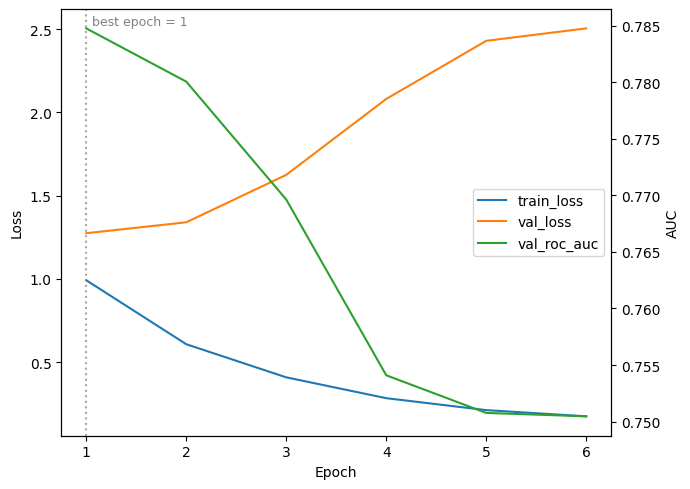

In [ ]:
# =========================
# 3. History 그래프
# =========================

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(7, 5))

# 왼쪽 축: loss
ax1.plot(history_v1_df["epoch"], history_v1_df["train_loss"], color="tab:blue", label="train_loss")
ax1.plot(history_v1_df["epoch"], history_v1_df["val_loss"], color="tab:orange", label="val_loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# 오른쪽 축: AUC (0~1 스케일이라 loss 와 같은 축에 두면 안 됨)
ax2 = ax1.twinx()
ax2.plot(history_v1_df["epoch"], history_v1_df["val_mean_roc_auc"], color="tab:green", label="val_roc_auc")
# ax2.plot(history_v1_df["epoch"], history_v1_df["val_mean_pr_auc"], color="tab:red", linestyle="--", label="val_pr_auc")
ax2.set_ylabel("AUC")

# best epoch 표시
best_ep = best_info_v1["best_epoch"]
ax1.axvline(best_ep, color="gray", linestyle=":", alpha=0.7)
ax1.annotate(f"best epoch = {best_ep}", xy=(best_ep, ax1.get_ylim()[1]),
             xytext=(4, -4), textcoords="offset points", va="top", fontsize=9, color="gray")

# twinx 는 범례가 축마다 따로라 합쳐줌
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

# plt.title("Training history (v1)")
plt.tight_layout()
plt.show()



In [ ]:
# # =========================
# # 4. Save (모델 + best_info + config 함께 저장)
# # =========================
# torch.save(
#     {
#         "model_state_dict": model_v1.state_dict(),
#         "best_info": best_info_v1,
#         "config": {
#             "hidden_dims": (512, 256), "dropout": 0.2,
#             "lr": 1e-3, "weight_decay": 1e-5, "batch_size": 128,
#         },
#     },
#     "tox21_mlp_v1.pt",
# )
# # load:
# # ckpt = torch.load("tox21_mlp_v1.pt")
# # model.load_state_dict(ckpt["model_state_dict"])

In [ ]:
# =========================
# 5. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v1, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])


=== Validation Summary ===
Mean ROC-AUC: 0.7505
Mean PR-AUC : 0.3727
       task   roc_auc    pr_auc  n_valid  positive_ratio
0    task_0  0.811316  0.409645      734        0.042234
1    task_1  0.880761  0.624167      646        0.037152
2    task_2  0.745080  0.403279      627        0.145136
3    task_3  0.738469  0.396438      521        0.082534
4    task_4  0.715709  0.374564      573        0.120419
5    task_5  0.789341  0.427112      685        0.051095
6    task_6  0.671949  0.184597      598        0.035117
7    task_7  0.746153  0.465241      491        0.215886
8    task_8  0.701865  0.174466      689        0.046444
9    task_9  0.725429  0.241481      572        0.068182
10  task_10  0.810288  0.538264      527        0.216319
11  task_11  0.669264  0.233588      654        0.111621


# 2nd version (dropout 0.2 -> 0.3)

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"

set_seed(42)

model_v2, history_v2_df, per_task_history_v2_df, best_info_v2 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.3,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-5,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v2_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v2["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v2["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v2["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v2, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=0.9823 | val_loss=1.3281 | val_mean_pr_auc=0.3982 | val_mean_roc_auc=0.7921
Epoch 002 | train_loss=0.5721 | val_loss=1.4820 | val_mean_pr_auc=0.4221 | val_mean_roc_auc=0.7753
Epoch 003 | train_loss=0.3702 | val_loss=1.8931 | val_mean_pr_auc=0.4431 | val_mean_roc_auc=0.7792
Epoch 004 | train_loss=0.2591 | val_loss=2.3779 | val_mean_pr_auc=0.4149 | val_mean_roc_auc=0.7648
Epoch 005 | train_loss=0.2004 | val_loss=2.4350 | val_mean_pr_auc=0.3968 | val_mean_roc_auc=0.7511
Epoch 006 | train_loss=0.1582 | val_loss=2.8099 | val_mean_pr_auc=0.4146 | val_mean_roc_auc=0.7576
Early stopping at epoch 6

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
1      2    0.572097  1.481956         0.422110          0.775268
2      3    0.370189  1.893119         0.443104          0.779208
3      4    0.259103  2.377907         0.414878          0.764848
4      5    0.200352  2.435015         0.396782          0.751069
5      6    0.158

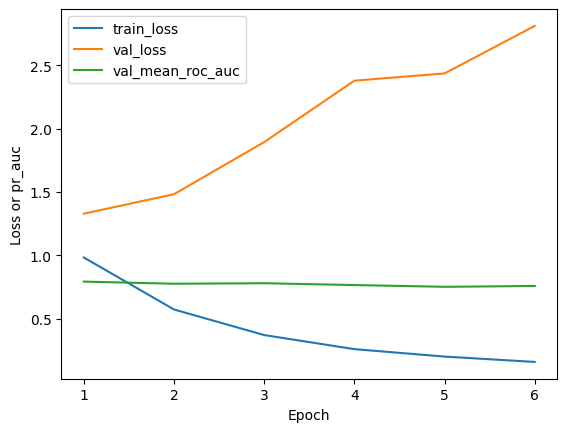

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v2_df["epoch"], history_v2_df["train_loss"], label="train_loss")
plt.plot(history_v2_df["epoch"], history_v2_df["val_loss"], label="val_loss")
plt.plot(history_v2_df["epoch"], history_v2_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# version 3 - adjust learning rate (1e-3 -> 3e-4)

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"

set_seed(42)

model_v3, history_v3_df, per_task_history_v3_df, best_info_v3 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.3,
    batch_size=128,
    lr=3e-4,
    weight_decay=1e-5,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v3_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v3["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v3["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v3["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v3, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=1.0671 | val_loss=1.2545 | val_mean_pr_auc=0.3917 | val_mean_roc_auc=0.7848
Epoch 002 | train_loss=0.7348 | val_loss=1.2383 | val_mean_pr_auc=0.4194 | val_mean_roc_auc=0.7944
Epoch 003 | train_loss=0.5379 | val_loss=1.3175 | val_mean_pr_auc=0.4443 | val_mean_roc_auc=0.7916
Epoch 004 | train_loss=0.4001 | val_loss=1.4503 | val_mean_pr_auc=0.4442 | val_mean_roc_auc=0.7874
Epoch 005 | train_loss=0.3071 | val_loss=1.5329 | val_mean_pr_auc=0.4419 | val_mean_roc_auc=0.7774
Epoch 006 | train_loss=0.2441 | val_loss=1.7296 | val_mean_pr_auc=0.4347 | val_mean_roc_auc=0.7759
Epoch 007 | train_loss=0.1930 | val_loss=1.9206 | val_mean_pr_auc=0.4032 | val_mean_roc_auc=0.7662
Early stopping at epoch 7

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
2      3    0.537853  1.317510         0.444263          0.791574
3      4    0.400146  1.450281         0.444221          0.787435
4      5    0.307076  1.532904         0.441905   

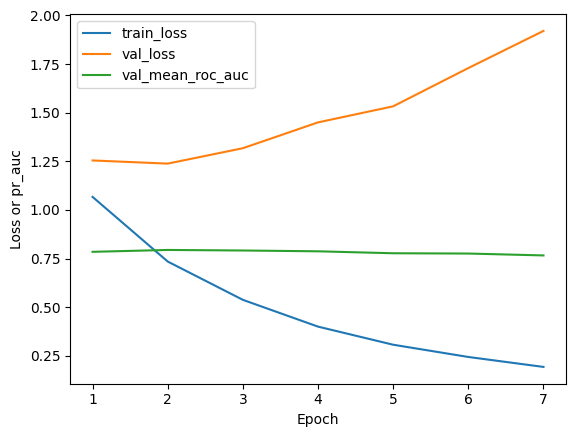

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v3_df["epoch"], history_v3_df["train_loss"], label="train_loss")
plt.plot(history_v3_df["epoch"], history_v3_df["val_loss"], label="val_loss")
plt.plot(history_v3_df["epoch"], history_v3_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# version 4 learning rate = 5e-4

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)

model_v4, history_v4_df, per_task_history_v4_df, best_info_v4 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.3,
    batch_size=128,
    lr=3e-4,
    weight_decay=1e-5,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v4_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v4["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v4["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v4["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v4, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=1.0671 | val_loss=1.2545 | val_mean_pr_auc=0.3917 | val_mean_roc_auc=0.7848
Epoch 002 | train_loss=0.7348 | val_loss=1.2383 | val_mean_pr_auc=0.4194 | val_mean_roc_auc=0.7944
Epoch 003 | train_loss=0.5379 | val_loss=1.3175 | val_mean_pr_auc=0.4443 | val_mean_roc_auc=0.7916
Epoch 004 | train_loss=0.4001 | val_loss=1.4503 | val_mean_pr_auc=0.4442 | val_mean_roc_auc=0.7874
Epoch 005 | train_loss=0.3071 | val_loss=1.5329 | val_mean_pr_auc=0.4419 | val_mean_roc_auc=0.7774
Epoch 006 | train_loss=0.2441 | val_loss=1.7296 | val_mean_pr_auc=0.4347 | val_mean_roc_auc=0.7759
Epoch 007 | train_loss=0.1930 | val_loss=1.9206 | val_mean_pr_auc=0.4032 | val_mean_roc_auc=0.7662
Early stopping at epoch 7

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
2      3    0.537853  1.317510         0.444263          0.791574
3      4    0.400146  1.450281         0.444221          0.787435
4      5    0.307076  1.532904         0.441905   

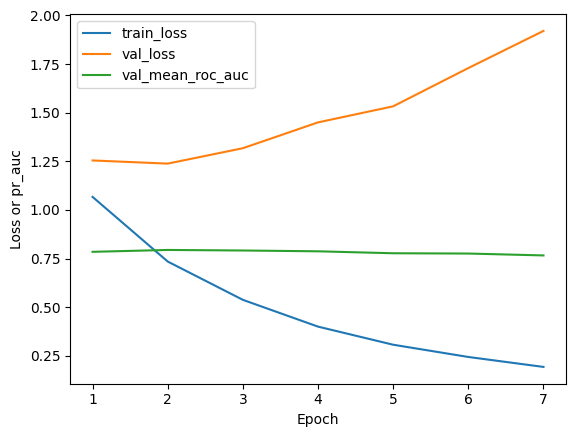

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v4_df["epoch"], history_v4_df["train_loss"], label="train_loss")
plt.plot(history_v4_df["epoch"], history_v4_df["val_loss"], label="val_loss")
plt.plot(history_v4_df["epoch"], history_v4_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# version 5 - weight decay (1e-5 -> 1e-4)
모델의 weight(가중치)가 너무 커지지 않게 억제하는 규제(regularization)

`Loss = BCE loss + λ * ||w||²`

모델이 train 데이터에 과하게 맞춤 (overfitting) → weight 값이 점점 커짐

예: w = [0.1, 0.2, 0.3] → [2.5, -3.1, 4.8] → 더 커짐

이런 모델은: train 성능 ↑ / val/test 성능 ↓
-> weight decay: "weight를 너무 크게 만들지 마라"

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v5, history_v5_df, per_task_history_v5_df, best_info_v5 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.3,
    batch_size=128,
    lr=3e-4,
    weight_decay=1e-4,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v5_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v5["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v5["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v5["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v5, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=1.0671 | val_loss=1.2536 | val_mean_pr_auc=0.3921 | val_mean_roc_auc=0.7847
Epoch 002 | train_loss=0.7359 | val_loss=1.2408 | val_mean_pr_auc=0.4186 | val_mean_roc_auc=0.7939
Epoch 003 | train_loss=0.5383 | val_loss=1.3189 | val_mean_pr_auc=0.4449 | val_mean_roc_auc=0.7913
Epoch 004 | train_loss=0.4016 | val_loss=1.4495 | val_mean_pr_auc=0.4458 | val_mean_roc_auc=0.7871
Epoch 005 | train_loss=0.3082 | val_loss=1.5320 | val_mean_pr_auc=0.4443 | val_mean_roc_auc=0.7784
Epoch 006 | train_loss=0.2453 | val_loss=1.7056 | val_mean_pr_auc=0.4366 | val_mean_roc_auc=0.7758
Epoch 007 | train_loss=0.1948 | val_loss=1.9033 | val_mean_pr_auc=0.4057 | val_mean_roc_auc=0.7668
Early stopping at epoch 7

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
2      3    0.538317  1.318916         0.444904          0.791299
3      4    0.401632  1.449502         0.445831          0.787126
4      5    0.308241  1.531973         0.444343   

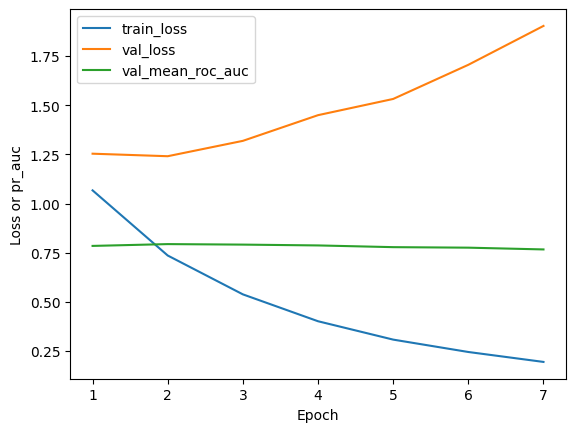

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v5_df["epoch"], history_v5_df["train_loss"], label="train_loss")
plt.plot(history_v5_df["epoch"], history_v5_df["val_loss"], label="val_loss")
plt.plot(history_v5_df["epoch"], history_v5_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# version 6 - weight decay (1e-4 -> 3e-4)

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v6, history_v6_df, per_task_history_v6_df, best_info_v6 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.3,
    batch_size=128,
    lr=3e-4,
    weight_decay=3e-4,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v6_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v6["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v6["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v6["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v6, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=1.0672 | val_loss=1.2542 | val_mean_pr_auc=0.3901 | val_mean_roc_auc=0.7848
Epoch 002 | train_loss=0.7364 | val_loss=1.2370 | val_mean_pr_auc=0.4166 | val_mean_roc_auc=0.7944
Epoch 003 | train_loss=0.5395 | val_loss=1.3134 | val_mean_pr_auc=0.4479 | val_mean_roc_auc=0.7924
Epoch 004 | train_loss=0.4036 | val_loss=1.4392 | val_mean_pr_auc=0.4479 | val_mean_roc_auc=0.7882
Epoch 005 | train_loss=0.3110 | val_loss=1.5093 | val_mean_pr_auc=0.4454 | val_mean_roc_auc=0.7802
Epoch 006 | train_loss=0.2491 | val_loss=1.6807 | val_mean_pr_auc=0.4361 | val_mean_roc_auc=0.7780
Epoch 007 | train_loss=0.1977 | val_loss=1.8650 | val_mean_pr_auc=0.4025 | val_mean_roc_auc=0.7673
Early stopping at epoch 7

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
2      3    0.539541  1.313363         0.447944          0.792391
3      4    0.403589  1.439187         0.447876          0.788230
4      5    0.311041  1.509251         0.445431   

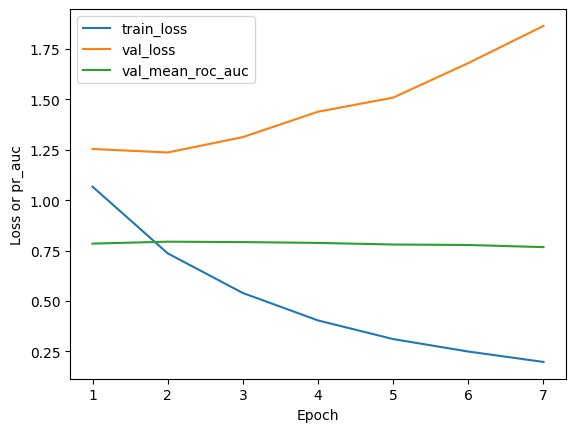

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v6_df["epoch"], history_v6_df["train_loss"], label="train_loss")
plt.plot(history_v6_df["epoch"], history_v6_df["val_loss"], label="val_loss")
plt.plot(history_v6_df["epoch"], history_v6_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# Version 7 Dropout (0.3 -> 0.4)

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v7, history_v7_df, per_task_history_v7_df, best_info_v7 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.4,
    batch_size=128,
    lr=3e-4,
    weight_decay=3e-4,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v7_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v7["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v7["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v7["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v7, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=1.0994 | val_loss=1.2749 | val_mean_pr_auc=0.3755 | val_mean_roc_auc=0.7756
Epoch 002 | train_loss=0.8003 | val_loss=1.2365 | val_mean_pr_auc=0.4042 | val_mean_roc_auc=0.7933
Epoch 003 | train_loss=0.6185 | val_loss=1.2743 | val_mean_pr_auc=0.4297 | val_mean_roc_auc=0.7934
Epoch 004 | train_loss=0.4841 | val_loss=1.3408 | val_mean_pr_auc=0.4412 | val_mean_roc_auc=0.7892
Epoch 005 | train_loss=0.3893 | val_loss=1.3914 | val_mean_pr_auc=0.4377 | val_mean_roc_auc=0.7810
Epoch 006 | train_loss=0.3201 | val_loss=1.5539 | val_mean_pr_auc=0.4369 | val_mean_roc_auc=0.7761
Epoch 007 | train_loss=0.2602 | val_loss=1.6758 | val_mean_pr_auc=0.4212 | val_mean_roc_auc=0.7714
Epoch 008 | train_loss=0.2254 | val_loss=1.8172 | val_mean_pr_auc=0.4203 | val_mean_roc_auc=0.7672
Early stopping at epoch 8

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
3      4    0.484054  1.340764         0.441225          0.789165
4      5    0.389

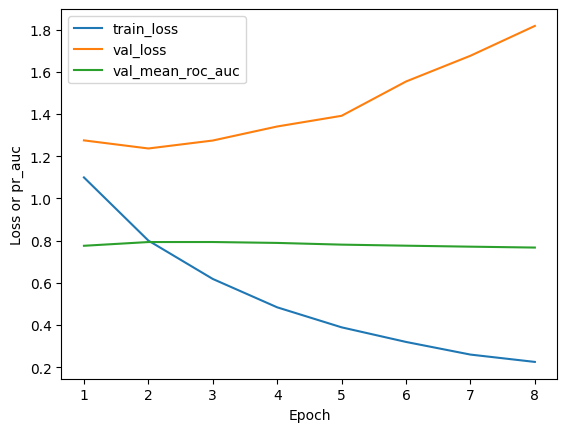

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v7_df["epoch"], history_v7_df["train_loss"], label="train_loss")
plt.plot(history_v7_df["epoch"], history_v7_df["val_loss"], label="val_loss")
plt.plot(history_v7_df["epoch"], history_v7_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# version 8 - batch size (128 -> 64)

작은 batch가 regularization처럼 작동해서 val PR-AUC가 약간 좋아지는 경우가 있어요.

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v8, history_v8_df, per_task_history_v8_df, best_info_v8 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.4,
    batch_size=64,
    lr=3e-4,
    weight_decay=3e-4,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v8_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v8["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v8["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v8["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v8, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=1.0589 | val_loss=1.2399 | val_mean_pr_auc=0.3914 | val_mean_roc_auc=0.7927
Epoch 002 | train_loss=0.7504 | val_loss=1.2627 | val_mean_pr_auc=0.4031 | val_mean_roc_auc=0.7889
Epoch 003 | train_loss=0.5579 | val_loss=1.3078 | val_mean_pr_auc=0.4250 | val_mean_roc_auc=0.7871
Epoch 004 | train_loss=0.4266 | val_loss=1.5525 | val_mean_pr_auc=0.4398 | val_mean_roc_auc=0.7782
Epoch 005 | train_loss=0.3352 | val_loss=1.5437 | val_mean_pr_auc=0.4326 | val_mean_roc_auc=0.7753
Epoch 006 | train_loss=0.2781 | val_loss=1.7351 | val_mean_pr_auc=0.4477 | val_mean_roc_auc=0.7743
Early stopping at epoch 6

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
1      2    0.750380  1.262733         0.403129          0.788875
2      3    0.557891  1.307843         0.425041          0.787061
3      4    0.426627  1.552476         0.439800          0.778177
4      5    0.335200  1.543748         0.432644          0.775300
5      6    0.278

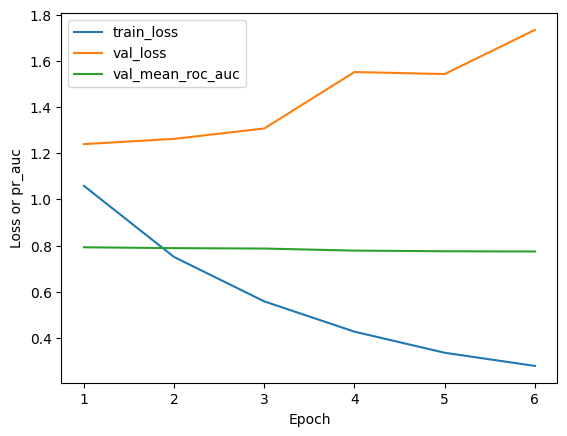

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v8_df["epoch"], history_v8_df["train_loss"], label="train_loss")
plt.plot(history_v8_df["epoch"], history_v8_df["val_loss"], label="val_loss")
plt.plot(history_v8_df["epoch"], history_v8_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# version 9 - batch size (64 -> 256)

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v9, history_v9_df, per_task_history_v9_df, best_info_v9 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.4,
    batch_size=256,
    lr=3e-4,
    weight_decay=3e-4,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)



# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v9_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v9["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v9["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v9["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v9, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=1.1396 | val_loss=1.4236 | val_mean_pr_auc=0.3292 | val_mean_roc_auc=0.7501
Epoch 002 | train_loss=0.8658 | val_loss=1.2487 | val_mean_pr_auc=0.4136 | val_mean_roc_auc=0.7906
Epoch 003 | train_loss=0.7072 | val_loss=1.2263 | val_mean_pr_auc=0.4267 | val_mean_roc_auc=0.7951
Epoch 004 | train_loss=0.5748 | val_loss=1.2621 | val_mean_pr_auc=0.4460 | val_mean_roc_auc=0.7937
Epoch 005 | train_loss=0.4773 | val_loss=1.3104 | val_mean_pr_auc=0.4521 | val_mean_roc_auc=0.7884
Epoch 006 | train_loss=0.4000 | val_loss=1.3431 | val_mean_pr_auc=0.4433 | val_mean_roc_auc=0.7849
Epoch 007 | train_loss=0.3372 | val_loss=1.4570 | val_mean_pr_auc=0.4393 | val_mean_roc_auc=0.7789
Epoch 008 | train_loss=0.2893 | val_loss=1.5620 | val_mean_pr_auc=0.4355 | val_mean_roc_auc=0.7740
Early stopping at epoch 8

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
3      4    0.574820  1.262127         0.446042          0.793725
4      5    0.477

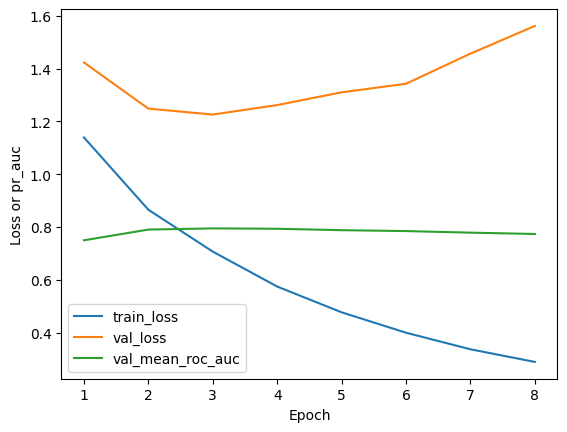

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v9_df["epoch"], history_v9_df["train_loss"], label="train_loss")
plt.plot(history_v9_df["epoch"], history_v9_df["val_loss"], label="val_loss")
plt.plot(history_v9_df["epoch"], history_v9_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v9_2, history_v9_2_df, per_task_history_v9_2_df, best_info_v9_2 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.4,
    batch_size=256,
    lr=3e-4,
    weight_decay=3e-4,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)



# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v9_2_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v9_2["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v9_2["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v9_2["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v9_2, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

# version 10 - pos_weight clipping 고려

task에 따라 positive가 너무 적으면 pos_weight가 과하게 커질 수 있어요.

예를 들어:

pos_weights.append(min(n_neg / max(n_pos, 1), 10.0))

이런 식으로 upper bound를 두면
학습이 더 안정될 수 있어요.


In [ ]:
# Python 함수 바인딩
# 1. 기본 케이스 - 함수 안에서 호출되는 함수는 이름으로 lookup합니다 (실행 시점) -> 그래서 최신에 재정의된 함수가 사용됨
# 2. B(x, f=A) 이런식으로 default argument로 박아버린 경우 / from module import A -> 함수 정의 시점에 A를 고정해서 저장함, 최근 정의된 함수가 아닌 옛날에 저장된 함수 그대로 호출됨

In [ ]:
# =========================
# 3-B. Pos weight 계산 - upper bound version
# =========================
def compute_pos_weight(y_train):
    """
    y_train: np.ndarray, shape (N, n_tasks), with np.nan
    반환: torch.FloatTensor of shape (n_tasks,)
    pos_weight = n_negative / n_positive
    """
    pos_weights = []  # positive(1) 클래스에 더 큰 중요도를 주기 위한 가중치 (pos_weight = n_negative / n_positive)
                                                                   # neg가 pos보다 9배 많으면, pos를 9배 중요하게 보겠다.
    for t in range(y_train.shape[1]): # task별로 반복               # 왜 필요하냐? 모델이 그냥 학습하면 "0이 훨씬 많네? 그냥 다 0으로 예측하면 되겠네
        y_t = y_train[:, t]                                        # pos_weight이 있으면 "positive 틀림 → 더 크게 벌점 / negative 틀림 → 덜 벌점
        valid = ~np.isnan(y_t)  # NaN 제거                          # => binary classification + imbalance 있을 때 거의 필수
        y_valid = y_t[valid]

        n_pos = np.sum(y_valid == 1)  # positive / negative 개수 계산
        n_neg = np.sum(y_valid == 0)

        if n_pos == 0:
            pos_weights.append(1.0) # 예외 처리 - positive 없으면, 그냥 weight 1로 둠 (neutral)
        else:
            pos_weights.append(min(n_neg / max(n_pos, 1), 10.0)) # weight 계산

    return torch.tensor(pos_weights, dtype=torch.float32)

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v10, history_v10_df, per_task_history_v10_df, best_info_v10 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.4,
    batch_size=256,
    lr=3e-4,
    weight_decay=3e-4,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v10_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v10["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v10["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v10["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v10, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=0.8498 | val_loss=1.0409 | val_mean_pr_auc=0.3372 | val_mean_roc_auc=0.7507
Epoch 002 | train_loss=0.6213 | val_loss=0.8890 | val_mean_pr_auc=0.4283 | val_mean_roc_auc=0.7973
Epoch 003 | train_loss=0.5084 | val_loss=0.8542 | val_mean_pr_auc=0.4468 | val_mean_roc_auc=0.8000
Epoch 004 | train_loss=0.4180 | val_loss=0.8620 | val_mean_pr_auc=0.4559 | val_mean_roc_auc=0.7957
Epoch 005 | train_loss=0.3489 | val_loss=0.8894 | val_mean_pr_auc=0.4550 | val_mean_roc_auc=0.7872
Epoch 006 | train_loss=0.2937 | val_loss=0.9199 | val_mean_pr_auc=0.4503 | val_mean_roc_auc=0.7836
Epoch 007 | train_loss=0.2462 | val_loss=0.9662 | val_mean_pr_auc=0.4419 | val_mean_roc_auc=0.7761
Epoch 008 | train_loss=0.2101 | val_loss=1.0480 | val_mean_pr_auc=0.4410 | val_mean_roc_auc=0.7705
Early stopping at epoch 8

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
3      4    0.418028  0.862019         0.455864          0.795691
4      5    0.348

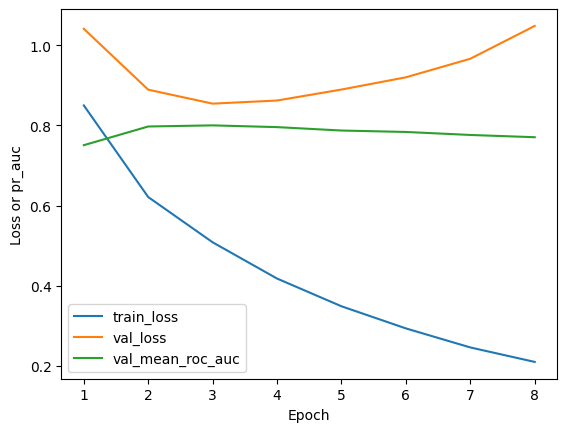

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v10_df["epoch"], history_v10_df["train_loss"], label="train_loss")
plt.plot(history_v10_df["epoch"], history_v10_df["val_loss"], label="val_loss")
plt.plot(history_v10_df["epoch"], history_v10_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# v 11 - weight decay 조정 (1e-4)

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v11, history_v11_df, per_task_history_v11_df, best_info_v11 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(1024, 512),
    dropout=0.4,
    batch_size=256,
    lr=3e-4,
    weight_decay=1e-4,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v11_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v11["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v11["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v11["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v11, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

Epoch 001 | train_loss=0.8498 | val_loss=1.0409 | val_mean_pr_auc=0.3362 | val_mean_roc_auc=0.7504
Epoch 002 | train_loss=0.6213 | val_loss=0.8888 | val_mean_pr_auc=0.4283 | val_mean_roc_auc=0.7972
Epoch 003 | train_loss=0.5082 | val_loss=0.8555 | val_mean_pr_auc=0.4449 | val_mean_roc_auc=0.7996
Epoch 004 | train_loss=0.4172 | val_loss=0.8623 | val_mean_pr_auc=0.4553 | val_mean_roc_auc=0.7956
Epoch 005 | train_loss=0.3478 | val_loss=0.8933 | val_mean_pr_auc=0.4559 | val_mean_roc_auc=0.7866
Epoch 006 | train_loss=0.2923 | val_loss=0.9280 | val_mean_pr_auc=0.4503 | val_mean_roc_auc=0.7816
Epoch 007 | train_loss=0.2448 | val_loss=0.9782 | val_mean_pr_auc=0.4394 | val_mean_roc_auc=0.7753
Epoch 008 | train_loss=0.2082 | val_loss=1.0611 | val_mean_pr_auc=0.4370 | val_mean_roc_auc=0.7698
Early stopping at epoch 8

=== Training History (tail) ===
   epoch  train_loss  val_loss  val_mean_pr_auc  val_mean_roc_auc
3      4    0.417231  0.862305         0.455343          0.795576
4      5    0.347

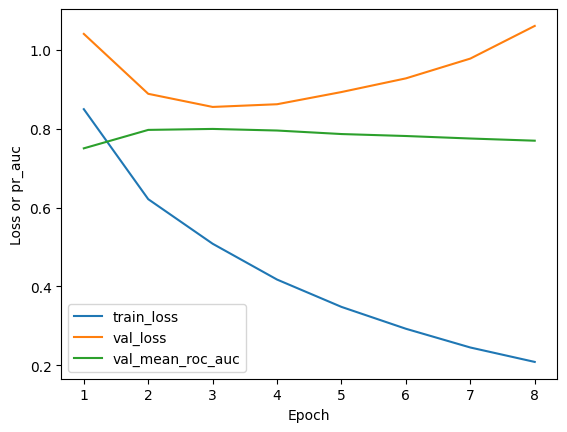

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v11_df["epoch"], history_v11_df["train_loss"], label="train_loss")
plt.plot(history_v11_df["epoch"], history_v11_df["val_loss"], label="val_loss")
plt.plot(history_v11_df["epoch"], history_v11_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

# Comparison of different config (without Optuna)

In [ ]:
"""
config 몇 개를 for 루프로 비교하기 (Optuna 없이).
- selection_metric="roc_auc" 패치([A])가 적용된 fit_tox21_mlp 를 가정.
- 공정 비교를 위해 config 마다 같은 seed 로 시작.
"""

import numpy as np
import pandas as pd
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── 비교할 config 목록: 손으로 몇 개만 정의 ──
configs = [
    {"name": "current",       "hidden_dims": (1024, 512), "dropout": 0.4, "lr": 3e-4, "weight_decay": 1e-4, "batch_size": 256},
    {"name": "smaller",       "hidden_dims": (512, 256),  "dropout": 0.5, "lr": 3e-4, "weight_decay": 1e-3, "batch_size": 256},
    {"name": "smaller+lowlr", "hidden_dims": (256, 128),  "dropout": 0.5, "lr": 1e-4, "weight_decay": 1e-3, "batch_size": 256},
]

results = []
trained = {}  # 모델/히스토리 보관 (나중에 best 꺼내 쓰려고)

for cfg in configs:
    name = cfg["name"]
    hp = {k: v for k, v in cfg.items() if k != "name"}  # name 빼고 나머지를 하이퍼파라미터로
    print(f"\n=== Running config: {name} ===")

    set_seed(42)  # 매 config 동일한 출발점

    model, history_df, per_task_df, best_info = fit_tox21_mlp(
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        max_epochs=100,
        patience=10,
        selection_metric="roc_auc",  # [A] 패치 가정
        device=device,
        **hp,                        # hidden_dims/dropout/lr/weight_decay/batch_size 펼쳐서 전달
    )

    results.append({
        "name": name,
        **hp,
        "best_epoch": best_info["best_epoch"],
        "best_val_roc_auc": round(best_info["best_val_roc_auc"], 4),
        "best_val_pr_auc": round(best_info["best_val_pr_auc"], 4),
    })
    trained[name] = {"model": model, "history": history_df, "per_task": per_task_df}


# ── 결과 비교 (val ROC-AUC 기준 정렬) ──
results_df = (
    pd.DataFrame(results)
    .sort_values("best_val_roc_auc", ascending=False)
    .reset_index(drop=True)
)
print("\n=== Config comparison ===")
print(results_df)

# ── 가장 좋은 config 꺼내기 ──
best_name = results_df.iloc[0]["name"]
best_model = trained[best_name]["model"]
print(f"\nBest config: {best_name} "
      f"(val ROC-AUC={results_df.iloc[0]['best_val_roc_auc']})")


=== Running config: current ===
Epoch 001 | train_loss=0.8498 | val_loss=1.0409 | val_mean_pr_auc=0.3362 | val_mean_roc_auc=0.7504
Epoch 002 | train_loss=0.6213 | val_loss=0.8888 | val_mean_pr_auc=0.4283 | val_mean_roc_auc=0.7972
Epoch 003 | train_loss=0.5082 | val_loss=0.8555 | val_mean_pr_auc=0.4449 | val_mean_roc_auc=0.7996
Epoch 004 | train_loss=0.4172 | val_loss=0.8623 | val_mean_pr_auc=0.4553 | val_mean_roc_auc=0.7956
Epoch 005 | train_loss=0.3478 | val_loss=0.8933 | val_mean_pr_auc=0.4559 | val_mean_roc_auc=0.7866
Epoch 006 | train_loss=0.2923 | val_loss=0.9280 | val_mean_pr_auc=0.4503 | val_mean_roc_auc=0.7816
Epoch 007 | train_loss=0.2448 | val_loss=0.9782 | val_mean_pr_auc=0.4394 | val_mean_roc_auc=0.7753
Epoch 008 | train_loss=0.2082 | val_loss=1.0611 | val_mean_pr_auc=0.4370 | val_mean_roc_auc=0.7698
Epoch 009 | train_loss=0.1775 | val_loss=1.0995 | val_mean_pr_auc=0.4414 | val_mean_roc_auc=0.7673
Epoch 010 | train_loss=0.1542 | val_loss=1.1232 | val_mean_pr_auc=0.4345 | v

# v12 best performing model

In [ ]:
# =========================
# 1. 모델 학습
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


model_v12, history_v12_df, per_task_history_v12_df, best_info_v12 = fit_tox21_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task_names=None,       # 리스트 넣어도 됨
    hidden_dims=(256, 128),
    dropout=0.5,
    batch_size=256,
    lr=1e-4,
    weight_decay=1e-3,
    max_epochs=100,
    patience=5,
    device=None  # 자동으로 cuda / cpu 선택
)


# =========================
# 2. 학습 결과 + best epoch (ROC 기준)
# =========================
print("\n=== Training History (tail) ===")
print(history_v12_df.tail())

print("\n=== Best epoch (selection_metric = roc_auc) ===")
print("Best epoch          :", best_info_v12["best_epoch"])
print("Best val mean ROC-AUC:", round(best_info_v12["best_val_roc_auc"], 4))
print("(ref) val mean PR-AUC:", round(best_info_v12["best_val_pr_auc"], 4))



# =========================
# 3. Validation 평가
# =========================
val_ds = Tox21MLPDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)  # eval 은 grad 없어서 batch 키워도 됨
val_summary = evaluate_multitask(model_v12, val_loader, device)

print("\n=== Validation Summary ===")
print("Mean ROC-AUC:", round(val_summary["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(val_summary["mean_pr_auc"], 4))
print(val_summary["per_task_df"])

In [ ]:
# Histroy graph
import matplotlib.pyplot as plt

plt.plot(history_v12_df["epoch"], history_v12_df["train_loss"], label="train_loss")
plt.plot(history_v12_df["epoch"], history_v12_df["val_loss"], label="val_loss")
plt.plot(history_v12_df["epoch"], history_v12_df["val_mean_roc_auc"], label="val_mean_roc_auc")


plt.xlabel("Epoch")
plt.ylabel("Loss or pr_auc")
plt.legend()
plt.show()

In [ ]:
# =========================
# 4. Test 평가
#    ※ 모델/하이퍼파라미터/config 를 '전부 확정한 뒤' 딱 한 번만.
#      v1, v2... 비교는 val 로만 하고, test 는 최종 1개 모델에만.
# =========================
test_ds = Tox21MLPDataset(X_test, y_test)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
test_summary_v12 = evaluate_multitask(model_v1, test_loader, device)

print("\n=== Test Summary ===")
print("Mean ROC-AUC:", round(test_summary_v12["mean_roc_auc"], 4))
print("Mean PR-AUC :", round(test_summary_v12["mean_pr_auc"], 4))

In [ ]:
# What I can try next: hyperparameter tuning with LR scheduler